<h1 align="center"> DOTA2 Hero Performance Predictor </h1>


<h2> Введение </h2>

На данной лекции (и еще на парочке лекций потом) мы будем реализовывать различные прогностические модели, чтобы проверить, насколько точно они определяют, является ли герой успешным (High Win Rate) или неуспешным (Low Win Rate) в профессиональных матчах.

<h4> По мотивам кейса, рассмотренного в Зимней школе СберУнивера </h4>

<h2> Наши цели: </h2>
<ul>
<li> Проанализировать полученные данные. </li>
<li> Рассмотреть проблему сильного дисбаланса классов. </li>
<li> Использовать алгоритмы кластеризации </li>
<li> Использовать алгоритмы понижения размерности </li>

## Описание данных и постановка задачи:
**Задача:** В DOTA2 важно определить, является ли герой успешным в профессиональной сцене, чтобы покупатели могли принять решение о выборе персонажа.

**Данные**: Набор данных содержит информацию о героях DOTA2, включая их атрибуты, тип атаки, роли, статистику побед в профессиональных матчах.

**Целевая переменная:** Мы создадим бинарную переменную на основе 'Win Rate' - если Win Rate >= 50%, герой считается успешным (1), иначе неуспешным (0).

Набор данных может быть несбалансирован, так как успешные герои (с высоким процентом побед) могут быть реже, чем неуспешные. Это требует специальной обработки для правильного обучения моделей.

Датасет содержит как числовые, так и категориальные переменные (атрибуты, типы атак, роли), которые требуют предварительной обработки.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline


import seaborn as sns
import matplotlib.patches as mpatches
import time

import collections
from collections import Counter

import warnings
warnings.filterwarnings("ignore")

Загружаем данные со своей локальной машины.

In [2]:
df = pd.read_csv('/content/sample_data/dota2HeroPick.csv', index_col=0)

df.head()

,Name,Primary Attribute,Attack Type,Attack Range,Roles,Total Pro wins,Times Picked,Times Banned,Win Rate,Niche Hero?
0,Abaddon,all,Melee,150,"Support, Carry, Durable",8,24,61,33.33,False
1,Alchemist,str,Melee,150,"Carry, Support, Durable, Disabler, Initiator, ...",23,55,22,41.82,False
2,Ancient Apparition,int,Ranged,675,"Support, Disabler, Nuker",40,77,73,51.95,False
3,Anti-Mage,agi,Melee,150,"Carry, Escape, Nuker",40,66,78,60.61,False
4,Arc Warden,agi,Ranged,625,"Carry, Escape, Nuker",5,14,31,35.71,False


Небольшой описательный анализ.

In [3]:
df.describe()

,Attack Range,Total Pro wins,Times Picked,Times Banned,Win Rate
count,124.000000,124.000000,124.000000,124.000000,124.000000
mean,350.604839,91.975806,183.951613,255.112903,49.390726
std,200.271759,73.328691,143.145492,241.567349,6.317535
min,150.000000,4.000000,5.000000,18.000000,32.730000
25%,150.000000,40.750000,82.500000,80.000000,46.217500
50%,340.000000,79.000000,156.000000,185.500000,50.250000
75%,550.000000,106.000000,215.250000,325.000000,52.492500
max,700.000000,407.000000,801.000000,1049.000000,80.000000


Проверим на наличие пропусков в данных.

In [4]:
df.isnull().sum()

,0
Name,0
Primary Attribute,0
Attack Type,0
Attack Range,0
Roles,0
Total Pro wins,0
Times Picked,0
Times Banned,0
Win Rate,0
Niche Hero?,0



Выведем названия столбцов.

In [5]:
df.columns

Index(['Name', 'Primary Attribute', 'Attack Type', 'Attack Range', 'Roles',
       'Total Pro wins', 'Times Picked', 'Times Banned', 'Win Rate',
       'Niche Hero?'],
      dtype='object')

Создадим целевую переменную на основе Win Rate (успешные герои >= 50%, неуспешные < 50%).

In [6]:
# Создаем бинарную целевую переменную
df['High_Win_Rate'] = (df['Win Rate'] >= 50).astype(int)

print('Герои с низким Win Rate составляют', round(df['High_Win_Rate'].value_counts()[0]/len(df) * 100,2), '% данных')
print('Герои с высоким Win Rate составляют', round(df['High_Win_Rate'].value_counts()[1]/len(df) * 100,2), '% данных')

Герои с низким Win Rate составляют 46.77 % данных
Герои с высоким Win Rate составляют 53.23 % данных


In [7]:
# df['High_Win_Rate'].value_counts()  - возвращает словарик,
# где ключ - уникальные значения в столбце кол-во значений
print(df['High_Win_Rate'].value_counts())

# так как это словарь, то чтобы получить значения, обращаемся по ключу:
print(df['High_Win_Rate'].value_counts()[0])
print(df['High_Win_Rate'].value_counts()[1])

High_Win_Rate
1    66
0    58
Name: count, dtype: int64
58
66


In [8]:
#  вывод отношения классов целевой переменной, но записанный через f строку

low_wr = round(df['High_Win_Rate'].value_counts()[0]/len(df) * 100,2)
high_wr = round(df['High_Win_Rate'].value_counts()[1]/len(df) * 100,2)

print(f'Герои с низким Win Rate составляют {low_wr} % данных')
print(f'Герои с высоким Win Rate составляют {high_wr} % данных')

Герои с низким Win Rate составляют 46.77 % данных
Герои с высоким Win Rate составляют 53.23 % данных


**Важно!**

Обратите внимание, насколько несбалансированным является наш исходный набор данных! Большинство героев имеют низкий процент побед. Если мы используем этот массив данных в качестве основы для наших моделей прогнозирования и анализа, мы можем получить много ошибок, поскольку наши алгоритмы будут предполагать, что все герои неуспешны. Нам же критически важно сконцентрироваться именно на успешных героях.

Text(0.5, 1.0, 'Распределение классов \n (0: Низкий Win Rate || 1: Высокий Win Rate)')

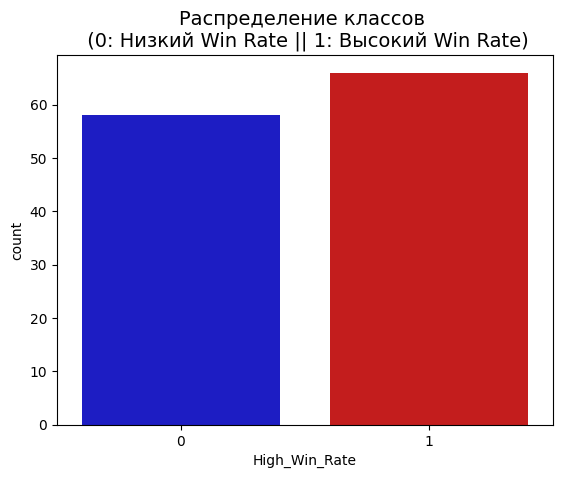

In [9]:
colors = ["#0101DF", "#DF0101"]

sns.countplot(x='High_Win_Rate', data=df, palette=colors) # строим гистограмму целевой переменной
plt.title('Распределение классов \n (0: Низкий Win Rate || 1: Высокий Win Rate)', fontsize=14)

Для упрощения анализа будем работать только с числовыми признаками.

In [10]:
# Оставляем только числовые колонны
df_numeric = df.select_dtypes(include=[np.number])

df_numeric.head()

,Attack Range,Total Pro wins,Times Picked,Times Banned,Win Rate,High_Win_Rate
0,150,8,24,61,33.33,0
1,150,23,55,22,41.82,0
2,675,40,77,73,51.95,1
3,150,40,66,78,60.61,1
4,625,5,14,31,35.71,0


### Разделение данных
**Важно!**

Прежде, чем приступить к балансировке наших данных, мы должны разделить исходный набор данных. Зачем?

Для определения качества работы наших моделей их необходимо тестировать на **исходном** тестовом наборе, а не на тестовом наборе, созданном после балансировки. Цель балансировки заключается в том, чтобы модель смогла найти закономерности для принятия решения, поэтому мы выравниваем соотношение между классами. Однако проверять качество мы будем именно в "боевых" условиях с учетом реального распределения данных.

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

rob_scaler = RobustScaler() # Менее чувствителен к выбросам, чем просто стандартизация

X = df_numeric.drop('High_Win_Rate', axis=1)
y = df_numeric['High_Win_Rate']

original_Xtrain, original_Xtest, original_ytrain, original_ytest = train_test_split(X, y, test_size=0.2,
                                                                                    random_state = 42)

# Масштабируем все признаки для единообразия
for col in X.columns:
    original_Xtrain[f'scaled_{col}'] = rob_scaler.fit_transform(original_Xtrain[col].values.reshape(-1,1))
    original_Xtest[f'scaled_{col}'] = rob_scaler.fit_transform(original_Xtest[col].values.reshape(-1,1))

# Используем масштабированные данные
original_Xtrain = original_Xtrain[[col for col in original_Xtrain.columns if col.startswith('scaled_')]].values
original_Xtest = original_Xtest[[col for col in original_Xtest.columns if col.startswith('scaled_')]].values
original_ytrain = original_ytrain.values
original_ytest = original_ytest.values

train_unique_label, train_counts_label = np.unique(original_ytrain, return_counts=True)
test_unique_label, test_counts_label = np.unique(original_ytest, return_counts=True)

print('Распределение классов: \n')
print("Обучающий набор:", train_counts_label/ len(original_ytrain))
print("Тестовый набор:", test_counts_label/ len(original_ytest))

Распределение классов: 

Обучающий набор: [0.44444444 0.55555556]
Тестовый набор: [0.56 0.44]


## Метод Random Under-Sampling

Применим метод *Random Under-Sampling*, который случайным образом удаляет объекты доминирующего класса и выравнивает соотношение классов.

#### Алгоритм:
<ul>
<li>Определяем степень несбалансированности (посчитали количество меток одного и другого класса выше)  </li>
<li>Как только мы определим, сколько героев с высоким Win Rate, мы должны довести количество героев с низким Win Rate до того же количества, чтобы получить соотношение 50/50 между классами.  </li>
<li> После применения этого метода мы получим подвыборку нашего набора данных с соотношением 50/50 в отношении наших классов. Наконец, не забудем <b>перемешать</b> наши данные для того, чтобы модели не зависели от порядка входных данных.</li>
</ul>

In [12]:
# Поскольку наши классы сильно не сбалансированы, мы должны сделать их эквивалентными,
# чтобы получить нормальное распределение классов.

# Перемешаем данные перед созданием подвыборок
df_numeric = df_numeric.sample(frac=1)

high_wr_df = df_numeric.loc[df_numeric['High_Win_Rate'] == 1]
low_wr_df = df_numeric.loc[df_numeric['High_Win_Rate'] == 0][:len(high_wr_df)] # берем первые N записей

normal_distributed_df = pd.concat([high_wr_df, low_wr_df])

# Перемешивание строк датасета
new_df = normal_distributed_df.sample(frac=1, random_state=42)

new_df.head()

,Attack Range,Total Pro wins,Times Picked,Times Banned,Win Rate,High_Win_Rate
16,650,22,36,173,61.11,1
6,400,84,152,104,55.26,1
114,575,41,79,260,51.90,1
0,150,8,24,61,33.33,0
59,150,4,5,49,80.00,1


In [13]:
new_df.shape

(124, 6)

Распределение классов в подвыборке
High_Win_Rate
1    0.532258
0    0.467742
Name: count, dtype: float64


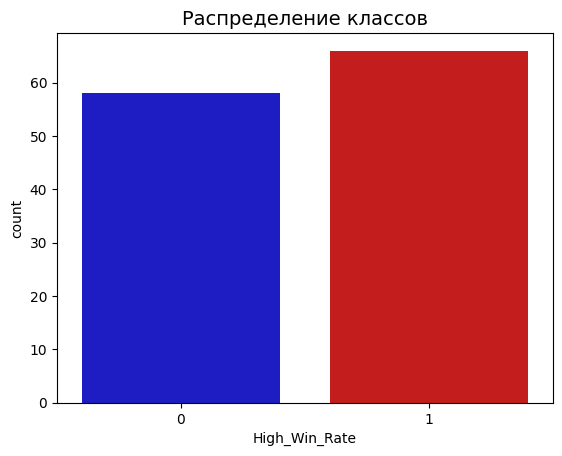

In [14]:
print('Распределение классов в подвыборке')
print(new_df['High_Win_Rate'].value_counts()/len(new_df))

# проверяем снова распределение целевой переменной
sns.countplot(x='High_Win_Rate', data = new_df, palette = colors)
plt.title('Распределение классов', fontsize=14)
plt.show()

### Матрица корреляций

Корреляционные матрицы очень важны для понимания данных. Мы хотим узнать, есть ли признаки, которые оказывают сильное влияние на то, является ли герой успешным. Однако важно, чтобы мы использовали сбалансированную подвыборку, чтобы увидеть, какие признаки имеют высокую положительную или отрицательную корреляцию в отношении целевого класса.

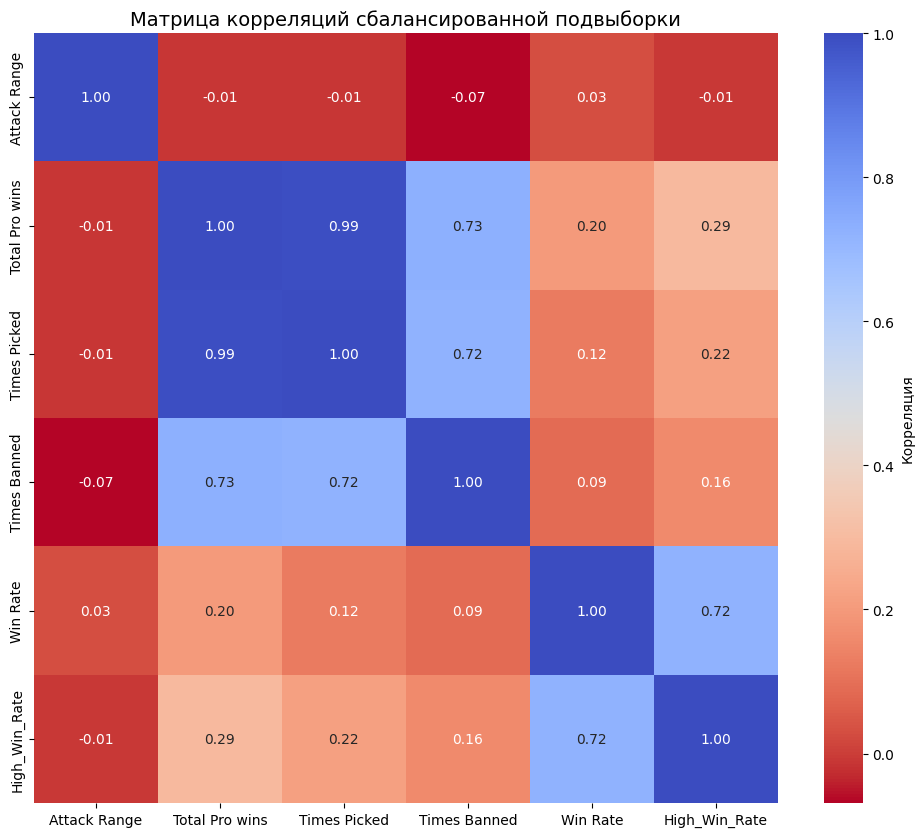

In [15]:
f, ax = plt.subplots(1, 1, figsize=(12, 10))

# Построим матрицу корреляций

sub_sample_corr = new_df.corr()
sns.heatmap(sub_sample_corr, cmap = 'coolwarm_r', annot=True, fmt='.2f', ax=ax, cbar_kws={'label': 'Корреляция'})
ax.set_title('Матрица корреляций сбалансированной подвыборки', fontsize=14)
plt.show()

### Выводы:
<ul>
<li><b>Отрицательные корреляции: </b>Признаки с отрицательной корреляцией означают, что чем ниже эти значения, тем больше вероятность того, что герой будет успешным.  </li>
<li> <b> Положительные корреляции: </b> Признаки с положительной корреляцией означают, что чем выше эти значения, тем больше вероятность того, что герой будет успешным. </li>
</ul>


**Важно!**

Всегда проверяйте, используете ли вы сбалансированную подвыборку в корреляционной матрице, иначе на корреляционную матрицу повлияет сильный дисбаланс между классами.

### Понижение размерности и кластеризация

Для того, чтобы убедиться, что наши классы являются разделимыми (иначе строить модели нет смысла), выполним кластеризацию с помощью трех различных техник кластеризации.

In [16]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA, TruncatedSVD

X = new_df.drop('High_Win_Rate', axis=1)
y = new_df['High_Win_Rate']


# T-SNE алгоритм
t0 = time.time()
X_reduced_tsne = TSNE(n_components=2, random_state=42).fit_transform(X.values)
t1 = time.time()
print("T-SNE заняло {:.2} сек".format(t1 - t0))

# PCA алгоритм
t0 = time.time()
X_reduced_pca = PCA(n_components=2, random_state=42).fit_transform(X.values)
t1 = time.time()
print("PCA заняло {:.2} сек".format(t1 - t0))

# TruncatedSVD алгоритм
t0 = time.time()
X_reduced_svd = TruncatedSVD(n_components=2, algorithm='randomized', random_state=42).fit_transform(X.values)
t1 = time.time()
print("Truncated SVD заняло {:.2} сек".format(t1 - t0))

T-SNE заняло 0.59 сек
PCA заняло 0.022 сек
Truncated SVD заняло 0.0021 сек


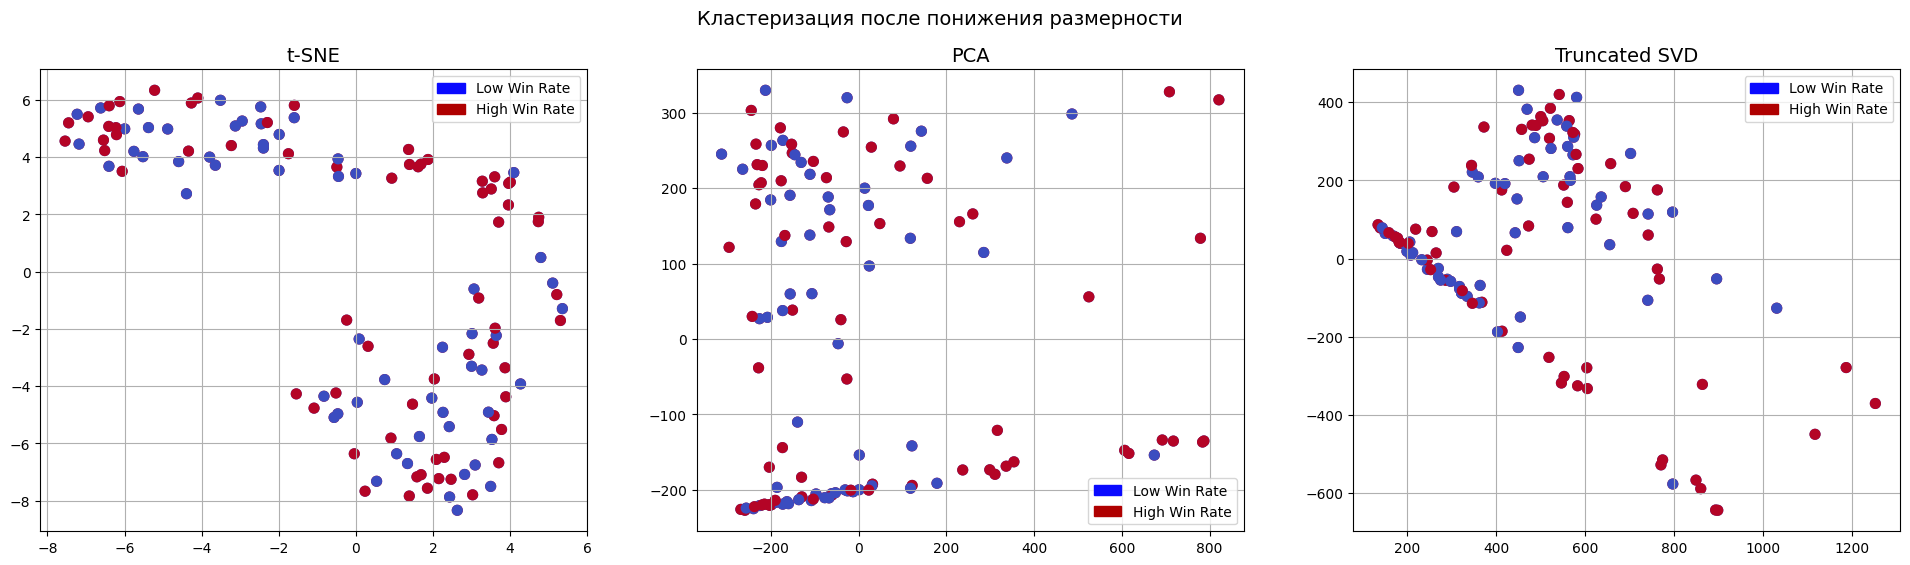

In [17]:
f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24,6))
f.suptitle('Кластеризация после понижения размерности', fontsize=14)


blue_patch = mpatches.Patch(color='#0A0AFF', label='Low Win Rate')
red_patch = mpatches.Patch(color='#AF0000', label='High Win Rate')


# t-SNE scatter plot
ax1.scatter(X_reduced_tsne[:,0], X_reduced_tsne[:,1], c=(y == 0), cmap='coolwarm', label='Low Win Rate', linewidths=2)
ax1.scatter(X_reduced_tsne[:,0], X_reduced_tsne[:,1], c=(y == 1), cmap='coolwarm', label='High Win Rate', linewidths=2)
ax1.set_title('t-SNE', fontsize=14)

ax1.grid(True)

ax1.legend(handles=[blue_patch, red_patch])


# PCA scatter plot
ax2.scatter(X_reduced_pca[:,0], X_reduced_pca[:,1], c=(y == 0), cmap='coolwarm', label='Low Win Rate', linewidths=2)
ax2.scatter(X_reduced_pca[:,0], X_reduced_pca[:,1], c=(y == 1), cmap='coolwarm', label='High Win Rate', linewidths=2)
ax2.set_title('PCA', fontsize=14)

ax2.grid(True)

ax2.legend(handles=[blue_patch, red_patch])

# TruncatedSVD scatter plot
ax3.scatter(X_reduced_svd[:,0], X_reduced_svd[:,1], c=(y == 0), cmap='coolwarm', label='Low Win Rate', linewidths=2)
ax3.scatter(X_reduced_svd[:,0], X_reduced_svd[:,1], c=(y == 1), cmap='coolwarm', label='High Win Rate', linewidths=2)
ax3.set_title('Truncated SVD', fontsize=14)

ax3.grid(True)

ax3.legend(handles=[blue_patch, red_patch])

plt.show()

<h3> Выводы: </h3>
<ul>
<li>Алгоритм t-SNE может довольно точно кластеризовать случаи успешных и неуспешных героев в нашем наборе данных. </li>
<li> Классы целевой переменной однозначно разделимы, а значит мы можем строить модели! </li>
</ul>

## Продолжение следует .....